# Conditional Quantum GAN — Patch Method

This notebook trains a **conditional** version of the patch-method quantum
GAN on the UCI handwritten digits dataset. Unlike the unconditional
tutorial (which generates only zeros), the model here learns to produce a
specific digit `c ∈ {0, ..., 9}` on demand.

## Conditioning approach

The classical conditioning lives entirely in the generator's latent
preprocessing. A learnable per-class rotation offset
`θ_class ∈ ℝ^{n_classes × n_qubits}` (a small `nn.Embedding`) is *added*
to the latent vector `z` before it enters every sub-generator's circuit:

```
z_eff[i] = z[i] + θ_class[c, i],   i = 0, ..., n_qubits - 1
```

Because consecutive `RY` rotations on the same qubit compose as
`RY(a) RY(b) = RY(a+b)`, this is mathematically identical to inserting per-class
`RY(θ_class[c, i])` rotations right after the state-embedding stage of the
circuit. The circuit topology in `qcircuit.py` therefore stays unchanged.

## Files

| Component | File |
| --- | --- |
| Quantum circuit (state embedding + parameterised layers + non-linear post-measurement) | `qcircuit.py` |
| Conditional patch quantum generator | `qgenerator.py` |
| Conditional discriminator | `discriminator.py` |
| Multi-class dataset wrapper | `dataset.py` |
| Shared evaluation suite | `metrics.py` |

The matched classical baseline lives in `classical_gan.ipynb`.

## Parameter budget

With the default hyper-parameters (`5` qubits, `1` ancilla, depth `6`,
`4` sub-generators, `10` classes):

* Sub-generator weights : `4 × 30 = 120`
* Class embedding (shared): `10 × 5 = 50`
* **Total: 170 trainable quantum-side parameters**

## 1. Imports and reproducibility

In [22]:
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

from dataset import DigitsDataset, IMAGE_SIZE, N_CLASSES, load_full_digits
from discriminator import ConditionalDiscriminator
from qcircuit import QCircuitConfig
from qgenerator import ConditionalPatchQuantumGenerator

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using torch device: {device}")
print(f"Number of classes: {N_CLASSES}")

Using torch device: cpu
Number of classes: 10


## 2. Data

`DigitsDataset` now keeps **all 10 classes** by default and returns
`(image, label)` pairs. We use a `WeightedRandomSampler` so that each
training batch contains a balanced mix of digit classes — important for
conditional training because each batch otherwise risks being dominated
by whichever classes are most numerous.

In [23]:
image_size = IMAGE_SIZE  # 8
batch_size = 8

transform = transforms.Compose([transforms.ToTensor()])
dataset = DigitsDataset(csv_file="data/optdigits.tra", label=None, transform=transform)

# Class-balanced sampling: per-sample weight = 1 / count(class_of_sample).
all_labels = np.array([dataset[i][1] for i in range(len(dataset))], dtype=np.int64)
class_counts = np.bincount(all_labels, minlength=N_CLASSES).astype(np.float64)
sample_weights = 1.0 / class_counts[all_labels]
sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(dataset),
    replacement=True,
)
dataloader = DataLoader(dataset, batch_size=batch_size, sampler=sampler, drop_last=True)

print(f"Dataset size: {len(dataset)}")
print(f"Class counts: {class_counts.astype(int).tolist()}")
print(f"Batch size: {batch_size}")

Dataset size: 3823
Class counts: [376, 389, 380, 389, 387, 376, 377, 387, 380, 382]
Batch size: 8


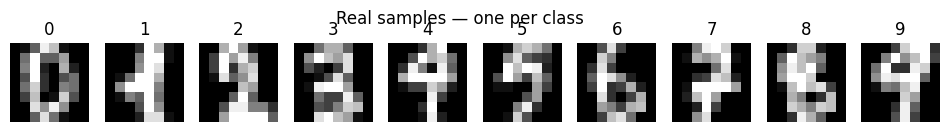

In [24]:
# One example per class (the row of "real" digits the generator must learn).
fig, axes = plt.subplots(1, N_CLASSES, figsize=(N_CLASSES * 1.2, 1.5))
for c in range(N_CLASSES):
    idx = int(np.where(all_labels == c)[0][0])
    img, lbl = dataset[idx]
    axes[c].imshow(img[0].numpy(), cmap="gray")
    axes[c].set_title(str(lbl))
    axes[c].axis("off")
fig.suptitle("Real samples — one per class")
plt.show()

## 3. Models

### Conditional discriminator

`ConditionalDiscriminator` takes the flattened image **and** the class
label, embeds the label with `nn.Embedding(10, 16)`, concatenates the
embedding with the image, and passes the result through a small MLP with
sigmoid output.

### Conditional patch quantum generator

`ConditionalPatchQuantumGenerator` keeps the original four sub-generators
(each a `5`-qubit, depth-`6`, `1`-ancilla circuit) and adds a tiny
classical preprocessing layer: a learnable per-class rotation offset
`θ_class ∈ ℝ^{10 × 5}` is added to the latent vector before it enters
each sub-generator's circuit. As discussed in the introduction this is
equivalent to inserting class-conditional `RY` rotations after the
state-embedding stage.

In [25]:
qcfg = QCircuitConfig(n_qubits=5, n_a_qubits=1, q_depth=6)
n_generators = 4

discriminator = ConditionalDiscriminator(
    n_classes=N_CLASSES, image_size=image_size, embed_dim=16
).to(device)

# `cond_init_scale=0.5` (vs. the default 0.1) enlarges the per-class
# rotation offset at initialisation. With the default the class signal
# (max ±0.1 rad) is dwarfed by the latent z (~0.45 stdev) and G never
# sees enough conditioning gradient — the classes collapse to a single
# generic mode early in training. The constructor argument is *only* an
# initialisation hyper-parameter — the parameter count, qubit topology
# and circuit depth are all unchanged.
generator = ConditionalPatchQuantumGenerator(
    n_generators=n_generators, n_classes=N_CLASSES, config=qcfg,
    cond_init_scale=0.5,
).to(device)

n_disc = sum(p.numel() for p in discriminator.parameters())
n_gen = sum(p.numel() for p in generator.parameters())
n_q = sum(p.numel() for p in generator.q_params)
n_emb = generator.class_emb.weight.numel()

print(f"Discriminator parameters         : {n_disc}")
print(f"Quantum generator parameters     : {n_gen}")
print(f"  - sub-generator weights        : {n_q}  ({n_generators} × {qcfg.n_weights})")
print(f"  - class embedding (shared)     : {n_emb}  ({N_CLASSES} × {qcfg.n_qubits})")
print(f"Patch size per sub-generator     : {qcfg.patch_size}")
print(f"Image size from quantum generator: {generator.output_size} pixels "
      f"({n_generators} patches × {qcfg.patch_size})")

Discriminator parameters         : 6401
Quantum generator parameters     : 170
  - sub-generator weights        : 120  (4 × 30)
  - class embedding (shared)     : 50  (10 × 5)
Patch size per sub-generator     : 16
Image size from quantum generator: 64 pixels (4 patches × 16)


### Inspecting the sub-generator circuit

The circuit is identical to the unconditional version — the conditioning
is handled by classical preprocessing of the latent vector.

In [26]:
import pennylane as qml
from qcircuit import make_quantum_circuit

_demo_circuit = make_quantum_circuit(qcfg)
_demo_noise = torch.rand(qcfg.n_qubits) * math.pi / 2
_demo_weights = torch.rand(qcfg.n_weights)
print(qml.draw(_demo_circuit, max_length=120)(_demo_noise, _demo_weights))

0: ──RY(0.65)──RY(0.01)─╭●──RY(0.30)───────────╭●─────────RY(0.57)───────────╭●─────────RY(0.74)───────────╭●─────── ···
1: ──RY(1.32)──RY(0.74)─╰Z─╭●─────────RY(0.18)─╰Z────────╭●─────────RY(0.43)─╰Z────────╭●─────────RY(0.82)─╰Z─────── ···
2: ──RY(0.85)──RY(0.23)────╰Z────────╭●─────────RY(0.39)─╰Z────────╭●─────────RY(0.61)─╰Z────────╭●─────────RY(0.05) ···
3: ──RY(0.62)──RY(0.07)──────────────╰Z────────╭●─────────RY(0.45)─╰Z────────╭●─────────RY(0.18)─╰Z────────╭●─────── ···
4: ──RY(0.72)──RY(0.43)────────────────────────╰Z─────────RY(0.65)───────────╰Z─────────RY(0.92)───────────╰Z─────── ···

0: ··· ──RY(0.02)───────────╭●─────────RY(0.82)───────────╭●────────────────────────┤ ╭Probs
1: ··· ─╭●─────────RY(0.97)─╰Z────────╭●─────────RY(0.94)─╰Z────────╭●──────────────┤ ├Probs
2: ··· ─╰Z────────╭●─────────RY(0.49)─╰Z────────╭●─────────RY(0.03)─╰Z────────╭●────┤ ├Probs
3: ··· ──RY(0.84)─╰Z────────╭●─────────RY(0.60)─╰Z────────╭●─────────RY(0.99)─╰Z─╭●─┤ ├Probs
4: ··· ──RY(0.59)─────

## 4. Training

Both networks are trained with vanilla SGD and binary cross-entropy. For
the conditional GAN:

* Discriminator real-half: `D(real_imgs, real_labels)` should be → 1
* Discriminator fake-half: `D(generator(z, fake_labels), fake_labels)` should be → 0
* Generator: `D(generator(z, fake_labels), fake_labels)` should be → 1
  (non-saturating trick: minimise `−log D(G(z, y))`)

`fake_labels` are sampled uniformly in `{0, ..., 9}` for each fake batch
so the generator gets equal pressure on every class.

> **Wall-clock note:** every quantum forward pass is one circuit
> simulation, and the parameter-shift gradient adds two more passes per
> trainable parameter. Conditional training therefore takes longer than
> the unconditional case. The defaults below (`batch_size=8`,
> `num_iter=300`) target a runtime of roughly 12–25 minutes on a modern
> CPU. Lower `num_iter` for a quick smoke test or raise it for higher
> quality.

In [27]:
# Training-time tricks (no architecture changes — see the README's
# "Tuning" section for the diagnosis and supporting evidence):
#
# * Adam with TTUR-style learning rates (lrG ≫ lrD). Quantum gradients
#   are small and noisy; Adam's per-parameter scaling stabilises training
#   far better than the high-LR SGD used in the original PennyLane
#   tutorial, and giving G a 10× higher learning rate stops D from
#   saturating before G's 170 parameters can meaningfully update.
# * One-sided label smoothing (real targets = 0.9). G still aims at 1.0
#   so smoothing only damps D, keeping gradients alive when D is winning.
# * Matched fake labels: the fake batch's class labels are taken from
#   the real batch's labels so D evaluates real and fake examples for
#   the *same* class on every step.
# * **Matching-aware discriminator loss** (Reed et al. 2016, "Generative
#   Adversarial Text to Image Synthesis", §3.3). On top of the usual
#   {(real, correct_label) → real, (fake, *, label) → fake} pairs we
#   add (real_image, *wrong*_label) → fake. Without this term, D can
#   minimise its loss while completely ignoring the conditioning vector
#   — exactly the failure mode visible in the previous run's confusion
#   matrix (every requested class decoded as digit 8). Forcing D to
#   call a real image with the wrong label "fake" makes the gradient
#   that flows back into G actually depend on the class.
lrG = 1e-2
lrD = 1e-3
num_iter = 500
beta1 = 0.5

criterion = nn.BCELoss()
optD = optim.Adam(discriminator.parameters(), lr=lrD, betas=(beta1, 0.999))
optG = optim.Adam(generator.parameters(), lr=lrG, betas=(beta1, 0.999))

real_label_value = 0.9
fake_label_value = 0.0

# Fixed (z, y) pairs for visual progress tracking — one per class.
fixed_noise = torch.rand(N_CLASSES, qcfg.n_qubits, device=device) * math.pi / 2
fixed_labels = torch.arange(N_CLASSES, device=device)

results = []  # snapshots of (10,) generated images per class
loss_history = {"iter": [], "D": [], "G": []}

start_time = time.time()
counter = 0
done = False
while not done:
    for real_imgs, real_labels in dataloader:
        bsz = real_imgs.size(0)
        real_imgs = real_imgs.reshape(bsz, image_size * image_size).to(device)
        real_labels = real_labels.long().to(device)

        noise = torch.rand(bsz, qcfg.n_qubits, device=device) * math.pi / 2
        fake_labels = real_labels.clone()  # matched-label conditional signal
        fake_imgs = generator(noise, fake_labels)

        real_targets = torch.full((bsz,), real_label_value, device=device)
        fake_targets = torch.full((bsz,), fake_label_value, device=device)

        # Per-batch "wrong" labels: y' = (y + Uniform[1, N_CLASSES)) mod N
        # guarantees y' ≠ y for every example without needing rejection
        # sampling, which is essential for the match-aware D term below.
        wrong_offsets = torch.randint(1, N_CLASSES, real_labels.shape, device=device)
        wrong_labels = (real_labels + wrong_offsets) % N_CLASSES

        # --- Discriminator step ---
        # 1. (real, correct_label)  -> real (smoothed to 0.9)
        # 2. (fake, fake_label)     -> fake
        # 3. (real, *wrong*_label)  -> fake   <-- match-aware term
        discriminator.zero_grad()
        outD_real = discriminator(real_imgs, real_labels).view(-1)
        outD_fake = discriminator(fake_imgs.detach(), fake_labels).view(-1)
        outD_mismatch = discriminator(real_imgs, wrong_labels).view(-1)
        errD_real = criterion(outD_real, real_targets)
        errD_fake = criterion(outD_fake, fake_targets)
        errD_mismatch = criterion(outD_mismatch, fake_targets)
        errD_real.backward()
        errD_fake.backward()
        errD_mismatch.backward()
        errD = errD_real + errD_fake + errD_mismatch
        optD.step()

        # --- Generator step (non-saturating: G aims at the unsmoothed 1.0) ---
        generator.zero_grad()
        outD_fake = discriminator(fake_imgs, fake_labels).view(-1)
        errG = criterion(outD_fake, torch.full((bsz,), 1.0, device=device))
        errG.backward()
        optG.step()

        counter += 1
        d_val = errD.detach().item()
        g_val = errG.detach().item()
        loss_history["iter"].append(counter)
        loss_history["D"].append(d_val)
        loss_history["G"].append(g_val)

        if counter % 10 == 0:
            elapsed = time.time() - start_time
            print(
                f"Iter {counter:4d} | D loss {d_val:.3f} | "
                f"G loss {g_val:.3f} | elapsed {elapsed:6.1f}s"
            )
            with torch.no_grad():
                test_images = (
                    generator(fixed_noise, fixed_labels)
                    .view(N_CLASSES, 1, image_size, image_size)
                    .cpu()
                )
            if counter % 50 == 0:
                results.append(test_images)

        if counter >= num_iter:
            done = True
            break

total_train_time = time.time() - start_time
print(f"Training finished in {total_train_time:.1f}s")

KeyboardInterrupt: 

## 5. Visualising the results

Two views give us a feel for how training progressed:

1. The **loss curves** for the discriminator and generator.
2. A **per-class snapshot grid** showing how the generator's response to a
   fixed `(z, y=0..9)` evolves over training (one row per snapshot, ten
   columns for the ten classes).

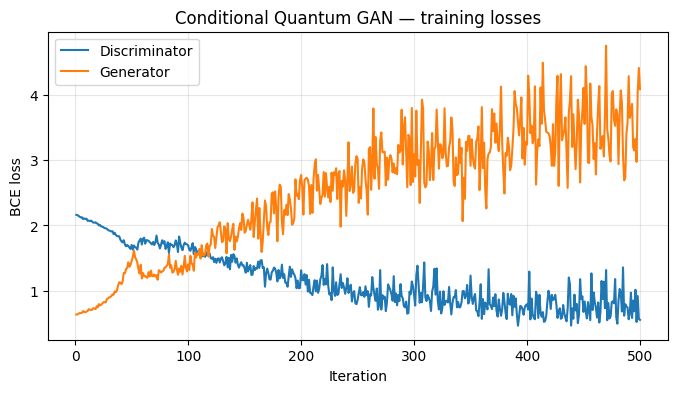

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history["iter"], loss_history["D"], label="Discriminator")
plt.plot(loss_history["iter"], loss_history["G"], label="Generator")
plt.xlabel("Iteration")
plt.ylabel("BCE loss")
plt.title("Conditional Quantum GAN — training losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

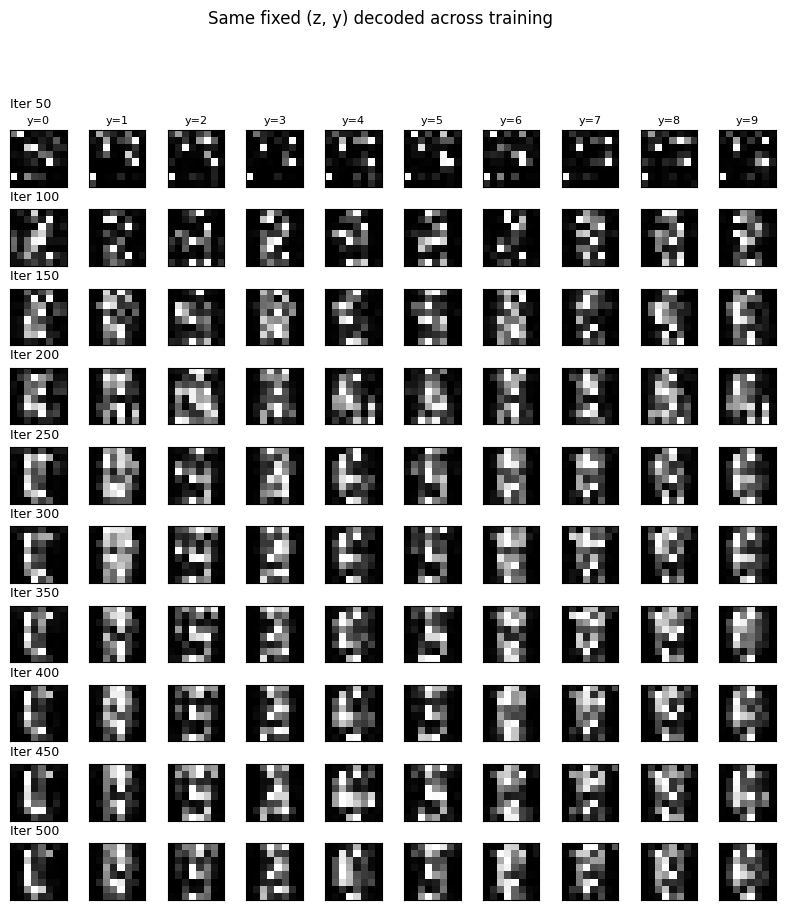

In [ ]:
if results:
    fig = plt.figure(figsize=(N_CLASSES * 1.0, len(results) * 1.0))
    outer = gridspec.GridSpec(len(results), 1, hspace=0.4)
    for i, images in enumerate(results):
        inner = gridspec.GridSpecFromSubplotSpec(
            1, images.size(0), subplot_spec=outer[i]
        )
        images = torch.squeeze(images, dim=1)
        for j, im in enumerate(images):
            ax = plt.Subplot(fig, inner[j])
            ax.imshow(im.numpy(), cmap="gray")
            ax.set_xticks([]); ax.set_yticks([])
            if j == 0:
                ax.set_title(f"Iter {(i + 1) * 50}", loc="left", fontsize=9)
            if i == 0:
                ax.set_xlabel(f"y={j}", fontsize=8)
                ax.xaxis.set_label_position("top")
            fig.add_subplot(ax)
    fig.suptitle("Same fixed (z, y) decoded across training", y=1.0)
    plt.show()
else:
    print("No snapshots collected — increase num_iter to at least 50.")

## 6. Final samples — 10 per class

A 10×10 grid where row `c` shows ten generated samples conditioned on
class `c`. A well-trained model should give visually identifiable digits
along each row, with intra-row variation coming from different `z`.

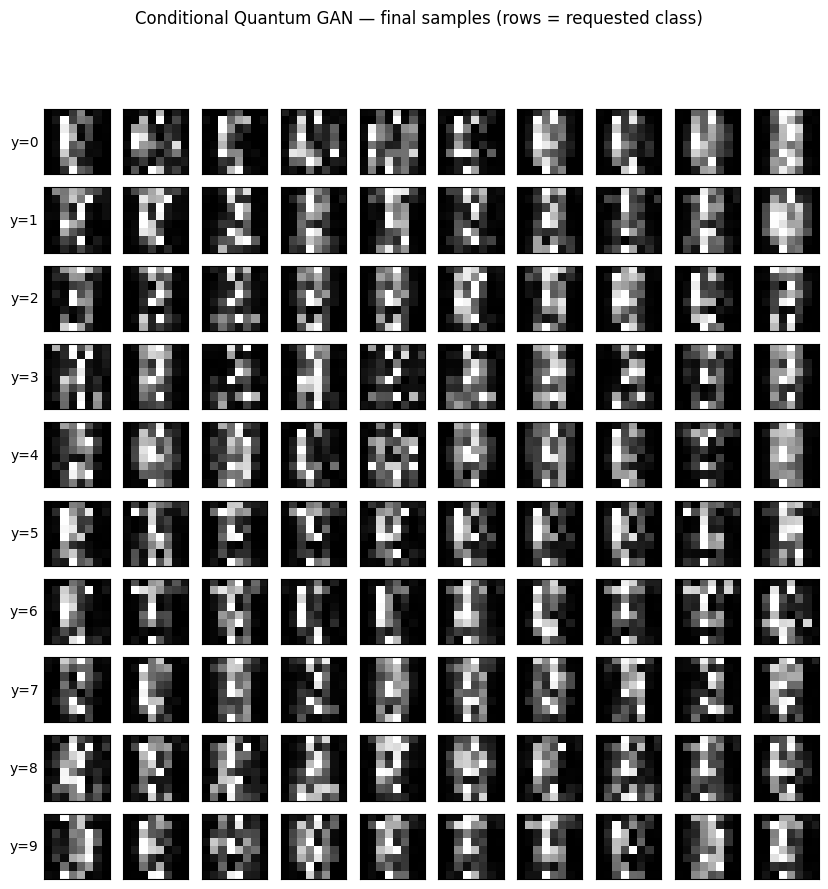

In [ ]:
samples_per_class = 10

generator.eval()
with torch.no_grad():
    grid_imgs = []
    for c in range(N_CLASSES):
        z = torch.rand(samples_per_class, qcfg.n_qubits, device=device) * math.pi / 2
        y = torch.full((samples_per_class,), c, dtype=torch.long, device=device)
        out = generator(z, y).view(samples_per_class, image_size, image_size).cpu()
        grid_imgs.append(out)

fig, axes = plt.subplots(N_CLASSES, samples_per_class,
                         figsize=(samples_per_class * 1.0, N_CLASSES * 1.0))
for c in range(N_CLASSES):
    for j in range(samples_per_class):
        ax = axes[c, j]
        ax.imshow(grid_imgs[c][j].numpy(), cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(f"y={c}", rotation=0, ha="right", va="center", fontsize=10)
fig.suptitle("Conditional Quantum GAN — final samples (rows = requested class)")
plt.show()

## 7. Quantitative evaluation

For the conditional setup the metrics suite from `metrics.py` becomes more
informative — many of them require the existence of multiple classes.

1. **Mode-collapse grid** (already shown above) — 10 samples per class.
2. **Latent-space interpolation** — interpolate `z` while holding `y`
   fixed; we should see a smooth morph within the same digit class.
3. **Pixel-level diversity** — mean pairwise L2 distance + per-pixel std.
4. **Judge confusion matrix** — for each requested class `y` we generate
   1000 samples, ask the Random-Forest judge what class it sees, and
   build a 10×10 `confusion[requested, predicted]` matrix. **Per-class
   accuracy** = diagonal entries / row sum. The judge IS is also
   reported.
5. **Domain-specific FID** — overall (real-all vs fake-all sampled
   uniformly across classes) plus a **per-class breakdown**
   (real-class-c vs fake-class-c).
6. **Standard Inception Score** — kept for completeness.
7. **Generation speed** — samples per second.

### 7.1 Train the judge and the domain-specific feature extractor

Both evaluators are trained on the *full* multi-class dataset and reused
for all metrics.

In [ ]:
import metrics as M

X_full, y_full = load_full_digits("data/optdigits.tra")
print(f"Full multi-class dataset: {X_full.shape}, classes: {sorted(set(y_full.tolist()))}")

print("\nTraining the Random-Forest judge on all 10 classes...")
judge = M.train_judge(X_full, y_full)

print("Training the domain-specific feature extractor (10-way classifier)...")
feat_extractor = M.train_feature_extractor(
    X_full, y_full, device=device, epochs=20, verbose=True
)

real_images_t = torch.from_numpy(X_full)
real_labels_t = torch.from_numpy(y_full)
print(f"\nReal multi-class samples for FID: {real_images_t.shape}")

Full multi-class dataset: (3823, 1, 8, 8), classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Training the Random-Forest judge on all 10 classes...
Training the domain-specific feature extractor (10-way classifier)...
  feature extractor epoch  1/20 | loss 1.9017 | acc 0.549
  feature extractor epoch  2/20 | loss 0.6017 | acc 0.903
  feature extractor epoch  3/20 | loss 0.2592 | acc 0.941
  feature extractor epoch  4/20 | loss 0.1900 | acc 0.954
  feature extractor epoch  5/20 | loss 0.1557 | acc 0.960
  feature extractor epoch  6/20 | loss 0.1332 | acc 0.967
  feature extractor epoch  7/20 | loss 0.1261 | acc 0.967
  feature extractor epoch  8/20 | loss 0.1089 | acc 0.973
  feature extractor epoch  9/20 | loss 0.1009 | acc 0.973
  feature extractor epoch 10/20 | loss 0.0905 | acc 0.976
  feature extractor epoch 11/20 | loss 0.0845 | acc 0.979
  feature extractor epoch 12/20 | loss 0.0783 | acc 0.982
  feature extractor epoch 13/20 | loss 0.0727 | acc 0.980
  feature extractor epoch 14/20 | loss

In [ ]:
# Conditional input samplers used by the metric helpers.
def quantum_sample_latent(n: int) -> torch.Tensor:
    return torch.rand(n, qcfg.n_qubits, device=device) * math.pi / 2


def quantum_sample_inputs(n: int):
    """Returns (z, y) with y ~ Uniform({0,...,9})."""
    z = quantum_sample_latent(n)
    y = torch.randint(0, N_CLASSES, (n,), device=device)
    return (z, y)

### 7.2 Latent-space interpolation (within a single class)

We interpolate `z` between two random points while holding the class
label fixed. A well-trained generator produces a smooth morph between
two instances of the same digit.

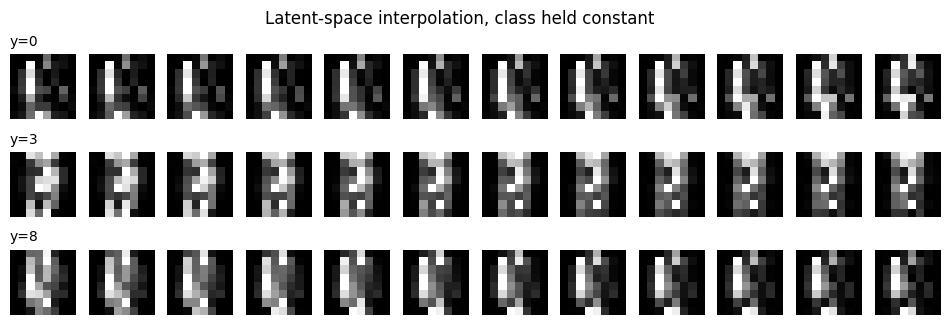

In [ ]:
interp_classes = [0, 3, 8]
n_steps = 12
fig, axes = plt.subplots(len(interp_classes), n_steps,
                         figsize=(n_steps * 1.0, len(interp_classes) * 1.2))
for row, c in enumerate(interp_classes):
    z_start = quantum_sample_latent(1)[0]
    z_end = quantum_sample_latent(1)[0]
    interp_z = M.interpolate_points(z_start, z_end, n_steps=n_steps).to(device)
    y_const = torch.full((n_steps,), c, dtype=torch.long, device=device)
    with torch.no_grad():
        imgs = generator(interp_z, y_const).view(n_steps, image_size, image_size).cpu()
    for j in range(n_steps):
        axes[row, j].imshow(imgs[j].numpy(), cmap="gray")
        axes[row, j].axis("off")
    axes[row, 0].set_title(f"y={c}", loc="left", fontsize=10)
fig.suptitle("Latent-space interpolation, class held constant")
plt.show()

### 7.3 Pixel-level diversity

Mean pairwise L2 distance + per-pixel std across 256 fakes (sampled with
classes drawn uniformly). Compared against the same statistic computed
on the real dataset for reference.

In [ ]:
diversity = M.compute_pixel_diversity(
    generator, quantum_sample_inputs, device=device, n_samples=256
)

real_flat = real_images_t.view(real_images_t.size(0), -1)
real_dists = torch.cdist(real_flat, real_flat, p=2)
mask = ~torch.eye(real_flat.size(0), dtype=torch.bool)
real_diversity = {
    "mean_pairwise_l2": float(real_dists[mask].mean().item()),
    "mean_pixel_std": float(real_flat.std(dim=0).mean().item()),
}
print("Real (all classes)  :", real_diversity)
print("Quantum generator   :", diversity)

Real (all classes)  : {'mean_pairwise_l2': 3.0229029655456543, 'mean_pixel_std': 0.23025280237197876}
Quantum generator   : {'mean_pairwise_l2': 2.50022029876709, 'mean_pixel_std': 0.1906544715166092}


### 7.4 Judge confusion matrix and class accuracy

For each random `(z, y)` pair we ask the Random-Forest judge "what digit
do you see?". The result is a 10×10 confusion matrix indexed as
`confusion[requested, predicted]`. The **diagonal** measures how often
the generator produced the *requested* class. The marginal class
distribution and judge IS are also reported.

Overall accuracy           : 0.209
Mean p(y_pred = y_req | x) : 0.150
Judge inception score      : 1.322
Predicted distribution     : [47, 45, 21, 209, 108, 51, 11, 55, 442, 11]

Per-class accuracy:
  y=0: 0.237
  y=1: 0.081
  y=2: 0.028
  y=3: 0.577
  y=4: 0.218
  y=5: 0.129
  y=6: 0.029
  y=7: 0.183
  y=8: 0.602
  y=9: 0.010


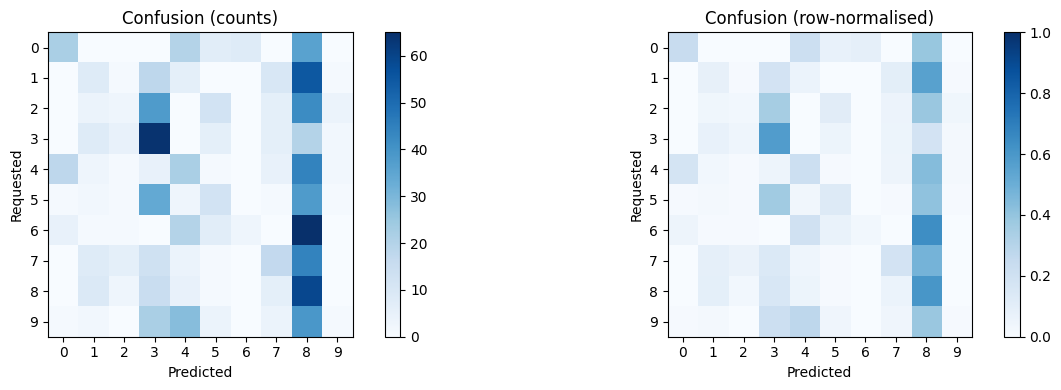

In [ ]:
judge_metrics = M.compute_judge_metrics(
    generator,
    quantum_sample_inputs,
    judge,
    device=device,
    n_samples=1000,
    n_classes=N_CLASSES,
)

print(f"Overall accuracy           : {judge_metrics['overall_accuracy']:.3f}")
print(f"Mean p(y_pred = y_req | x) : {judge_metrics['mean_target_confidence']:.3f}")
print(f"Judge inception score      : {judge_metrics['judge_inception_score']:.3f}")
print(f"Predicted distribution     : {judge_metrics['predicted_distribution'].tolist()}\n")

print("Per-class accuracy:")
for c, acc in enumerate(judge_metrics["per_class_accuracy"]):
    print(f"  y={c}: {acc:.3f}")

# Heatmap of the confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conf = judge_metrics["confusion_matrix"]
row_sums = conf.sum(axis=1, keepdims=True).clip(min=1)
conf_norm = conf / row_sums

im0 = axes[0].imshow(conf, cmap="Blues")
axes[0].set_title("Confusion (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Requested")
axes[0].set_xticks(range(N_CLASSES)); axes[0].set_yticks(range(N_CLASSES))
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(conf_norm, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Confusion (row-normalised)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Requested")
axes[1].set_xticks(range(N_CLASSES)); axes[1].set_yticks(range(N_CLASSES))
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

### 7.5 Domain-specific FID — overall and per-class

`compute_custom_fid` is the aggregate version (real-all vs fake-all,
sampled with classes uniform). `compute_per_class_fid` computes one FID
per class by comparing the real-class-c distribution against fakes
generated with `y = c`.

Overall (aggregate) FID: 50.8171

Per-class FID:
  y=0: 112.5752
  y=1: 69.9705
  y=2: 135.2543
  y=3: 82.0133
  y=4: 125.2513
  y=5: 118.3893
  y=6: 127.8647
  y=7: 117.4293
  y=8: 58.0949
  y=9: 105.6772


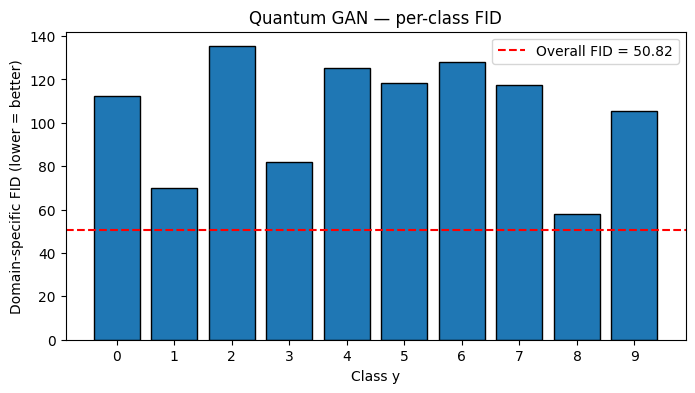

In [ ]:
fid_overall = M.compute_custom_fid(
    generator, quantum_sample_inputs, real_images_t, feat_extractor,
    device=device, n_samples=1000,
)

fid_per_class = M.compute_per_class_fid(
    generator,
    real_images=real_images_t,
    real_labels=real_labels_t,
    extractor=feat_extractor,
    device=device,
    sample_latent=quantum_sample_latent,
    n_samples_per_class=200,
    n_classes=N_CLASSES,
)

print(f"Overall (aggregate) FID: {fid_overall:.4f}\n")
print("Per-class FID:")
for c in range(N_CLASSES):
    print(f"  y={c}: {fid_per_class[c]:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(range(N_CLASSES), [fid_per_class[c] for c in range(N_CLASSES)],
        color="tab:blue", edgecolor="black")
plt.axhline(y=fid_overall, color="r", ls="--", label=f"Overall FID = {fid_overall:.2f}")
plt.xlabel("Class y")
plt.ylabel("Domain-specific FID (lower = better)")
plt.title("Quantum GAN — per-class FID")
plt.xticks(range(N_CLASSES))
plt.legend()
plt.show()

### 7.6 Standard Inception Score (for completeness)

Set `SKIP_STANDARD_IS = True` to bypass this on offline machines.

In [ ]:
SKIP_STANDARD_IS = False

if SKIP_STANDARD_IS:
    is_mean, is_std = float("nan"), float("nan")
    print("Skipping standard Inception Score (SKIP_STANDARD_IS=True).")
else:
    is_mean, is_std = M.compute_inception_score(
        generator, quantum_sample_inputs, device=device, n_samples=1024, batch_size=32
    )
    print(f"Standard Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    print("(Expected to be ~1.0 on 8x8 digits regardless of class diversity.)")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Standard Inception Score: 1.0018 ± 0.0003
(Expected to be ~1.0 on 8x8 digits regardless of class diversity.)


### 7.7 Generation speed

Quantum generator speed: 197.44 samples/sec


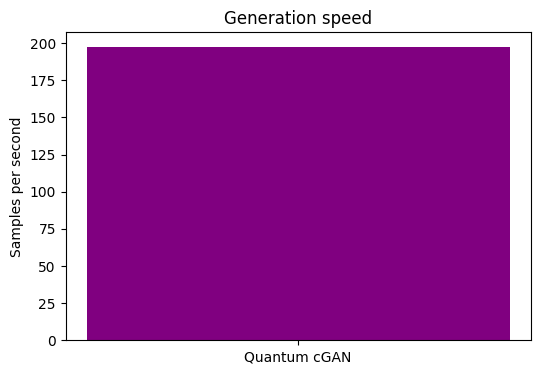

In [ ]:
gen_speed = M.measure_generation_speed(
    generator, quantum_sample_inputs, device=device, n_samples=256, batch_size=32
)
print(f"Quantum generator speed: {gen_speed:.2f} samples/sec")
plt.figure(figsize=(6, 4))
plt.bar(["Quantum cGAN"], [gen_speed], color="purple")
plt.title("Generation speed")
plt.ylabel("Samples per second")
plt.show()

### 7.8 Summary scoreboard

A single dict captures every metric we just computed; it is also written
into the checkpoint so the classical comparison notebook can pull it in
for a head-to-head plot.

In [ ]:
quantum_metrics = {
    "model": "Conditional Quantum GAN",
    "generator_params": M.count_parameters(generator),
    "discriminator_params": M.count_parameters(discriminator),
    "training_time_sec": float(total_train_time),
    "fid_overall": float(fid_overall),
    "fid_per_class": {int(c): float(v) for c, v in fid_per_class.items()},
    "inception_score_mean": float(is_mean),
    "inception_score_std": float(is_std),
    "judge_inception_score": float(judge_metrics["judge_inception_score"]),
    "overall_accuracy": float(judge_metrics["overall_accuracy"]),
    "mean_target_confidence": float(judge_metrics["mean_target_confidence"]),
    "per_class_accuracy": [float(a) for a in judge_metrics["per_class_accuracy"]],
    "predicted_distribution": [int(c) for c in judge_metrics["predicted_distribution"]],
    "mean_pairwise_l2": float(diversity["mean_pairwise_l2"]),
    "mean_pixel_std": float(diversity["mean_pixel_std"]),
    "samples_per_sec": float(gen_speed),
}

print("=" * 70)
print("Conditional Quantum GAN — quantitative evaluation")
print("=" * 70)
for k, v in quantum_metrics.items():
    if isinstance(v, float):
        print(f"  {k:25s} : {v:.4f}")
    elif isinstance(v, list):
        print(f"  {k:25s} : {[round(x, 3) if isinstance(x, float) else x for x in v]}")
    elif isinstance(v, dict):
        print(f"  {k:25s} : {{{', '.join(f'{k2}: {v2:.3f}' for k2, v2 in v.items())}}}")
    else:
        print(f"  {k:25s} : {v}")

Conditional Quantum GAN — quantitative evaluation
  model                     : Conditional Quantum GAN
  generator_params          : 170
  discriminator_params      : 6401
  training_time_sec         : 611.0898
  fid_overall               : 50.8171
  fid_per_class             : {0: 112.575, 1: 69.970, 2: 135.254, 3: 82.013, 4: 125.251, 5: 118.389, 6: 127.865, 7: 117.429, 8: 58.095, 9: 105.677}
  inception_score_mean      : 1.0018
  inception_score_std       : 0.0003
  judge_inception_score     : 1.3217
  overall_accuracy          : 0.2092
  mean_target_confidence    : 0.1504
  per_class_accuracy        : [0.237, 0.081, 0.028, 0.577, 0.218, 0.129, 0.029, 0.183, 0.602, 0.01]
  predicted_distribution    : [47, 45, 21, 209, 108, 51, 11, 55, 442, 11]
  mean_pairwise_l2          : 2.5002
  mean_pixel_std            : 0.1907
  samples_per_sec           : 197.4355


In [ ]:
torch.save(
    {
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "qcfg": qcfg.__dict__,
        "n_generators": n_generators,
        "n_classes": N_CLASSES,
        "loss_history": loss_history,
        "metrics": quantum_metrics,
    },
    "quantum_gan.pt",
)
print("Saved quantum_gan.pt")

Saved quantum_gan.pt


## 8. Pass 3 — Architectural changes

Pass 1 and Pass 2 above committed to keeping the network architecture
fixed and improving quality with optimizer / loss / init knobs alone.
That ran out of room on the quantum side: the Pass-2 generator has
**170 trainable parameters** trying to encode 10 distinct digit
shapes, against a discriminator with 6,401 parameters. The confusion
matrix above shows the symptom — most requested classes are decoded
as digit `8`, with only one or two well-modelled classes — and no
non-architectural lever closes the gap.

This section keeps the Pass-2 model, history, scoreboard and
checkpoint untouched (so the comparison is preserved), and trains a
**second** quantum cGAN with two architectural changes:

1. **AC-GAN style discriminator**
   ([Odena, Olah & Shlens 2017](https://arxiv.org/abs/1610.09585)).
   Instead of consuming the class label as an *input*, the
   discriminator predicts the class as an auxiliary *output* via a
   second linear head. D is jointly trained on real/fake (BCE) and
   class (cross-entropy), and G is trained against the same class
   head, so the generator now receives an explicit
   class-supervised gradient on every step. This replaces the
   "matching-aware mismatch" loss from Pass-2 with a stronger,
   always-on signal. (See `ConditionalDiscriminatorAC` in
   `discriminator.py`.)

2. **Larger patch quantum generator** — `q_depth` raised from 6 to
   10, which lifts each sub-generator from 30 → 50 weights. The
   total trainable parameter count rises from 170 to **250**, and
   per-iter wall-clock cost grows by roughly the same factor because
   the parameter-shift gradient is linear in the number of
   parameters. The qubit topology, ancilla count and patch layout
   are unchanged — this is the cheapest "more capacity" knob
   available.

All other Pass-2 settings carry over (Adam TTUR, label smoothing,
matched fake labels, `cond_init_scale=0.5`, 500 iters, batch 8).

### 8.1 Build the larger generator and the AC-GAN discriminator

In [ ]:
from discriminator import ConditionalDiscriminatorAC

# Larger quantum circuit — only q_depth changes.
ac_qcfg = QCircuitConfig(n_qubits=5, n_a_qubits=1, q_depth=10)
ac_n_generators = 4

# Re-seed so Pass-3 starts from a deterministic point.
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

ac_discriminator = ConditionalDiscriminatorAC(
    n_classes=N_CLASSES, image_size=image_size,
).to(device)
ac_generator = ConditionalPatchQuantumGenerator(
    n_generators=ac_n_generators, n_classes=N_CLASSES, config=ac_qcfg,
    cond_init_scale=0.5,
).to(device)

ac_n_disc = sum(p.numel() for p in ac_discriminator.parameters())
ac_n_gen = sum(p.numel() for p in ac_generator.parameters())
ac_n_q = sum(p.numel() for p in ac_generator.q_params)
ac_n_emb = ac_generator.class_emb.weight.numel()
print("Pass 3 — architectural changes")
print("-" * 60)
print(f"AC-GAN discriminator parameters    : {ac_n_disc} "
      f"(Pass-2 had {sum(p.numel() for p in discriminator.parameters())})")
print(f"  shared trunk : Linear(64,64) + Linear(64,16)")
print(f"  real/fake hd : Linear(16, 1) + Sigmoid")
print(f"  class head   : Linear(16, {N_CLASSES})")
print()
print(f"Wider quantum generator parameters : {ac_n_gen} "
      f"(Pass-2 had {sum(p.numel() for p in generator.parameters())})")
print(f"  - sub-generator weights        : {ac_n_q}  "
      f"({ac_n_generators} × {ac_qcfg.n_weights})")
print(f"  - class embedding (shared)     : {ac_n_emb}")
print(f"  q_depth                        : {ac_qcfg.q_depth}  (was 6)")
print(f"  patch_size per sub-generator   : {ac_qcfg.patch_size}")
print(f"  total image size               : {ac_generator.output_size} pixels")

Pass 3 — architectural changes
------------------------------------------------------------
AC-GAN discriminator parameters    : 5387 (Pass-2 had 6401)
  shared trunk : Linear(64,64) + Linear(64,16)
  real/fake hd : Linear(16, 1) + Sigmoid
  class head   : Linear(16, 10)

Wider quantum generator parameters : 250 (Pass-2 had 170)
  - sub-generator weights        : 200  (4 × 50)
  - class embedding (shared)     : 50
  q_depth                        : 10  (was 6)
  patch_size per sub-generator   : 16
  total image size               : 64 pixels


### 8.2 Training with AC-GAN losses

The loss now has two components on each side:

* **D loss** = `BCE(rf(real), 0.9) + BCE(rf(fake), 0.0) + λ · CE(class(real), real_labels) + λ · CE(class(fake), fake_labels)`
* **G loss** = `BCE(rf(fake), 1.0) + λ · CE(class(fake), fake_labels)` *(non-saturating)*

We pick `λ = 5.0` (heavier than the textbook AC-GAN value of 1.0) so
the auxiliary class signal dominates D's small
`Linear(64,64) → Linear(64,16)` trunk during the early adversarial
phase.

**Bootstrap step.** Before adversarial training begins we *pre-train
D's class head* on real labelled digits with plain supervised
cross-entropy for 200 mini-batches at `lr = 5e-3`. This is cheap
(under a second of wall-clock; no quantum forwards involved) and
converges the class head from a random `ln 10 ≈ 2.30` CE loss down
to roughly `0.2-0.3`, corresponding to ~90 % top-1 accuracy on real
digits.

Without this bootstrap the class head and the generator deadlock:
D's trunk has too few parameters to learn class-discriminative
features purely from the adversarial samples it sees in the first
few hundred iters, so G never receives an informative class
gradient. An un-bootstrapped run with `λ = 5.0` sat at
`D cls ≈ 4.0`, `G cls ≈ 2.0` (both near their random baselines) for
the first 40 iters before showing any movement. Pre-training removes
that warm-up phase: adversarial training then begins with a working
class judge, so G's class-CE gradient is informative from step 1.

We only update D during pre-training (G is untouched) and we use a
*separate optimiser* for the pretrain step so the adversarial
optimiser starts with fresh momentum on the warm-started parameters.

We keep one-sided label smoothing on the real / fake branch. The match-aware mismatch
term from Pass-2 is *removed* — the class head is now the
class-conditional pressure on D.

In [29]:
ac_lrG = 1e-2
ac_lrD = 1e-3
ac_num_iter = 500
ac_beta1 = 0.5
ac_lambda_cls = 5.0  # weight on the auxiliary class loss

ac_bce = nn.BCELoss()
ac_ce = nn.CrossEntropyLoss()
ac_optG = optim.Adam(ac_generator.parameters(), lr=ac_lrG, betas=(ac_beta1, 0.999))

# --- Pre-train D's class head on real labelled digits (Pass 3 bootstrap) ---
# AC-GAN's class head needs a non-random starting point so G receives
# informative gradients from step 1 of adversarial training. Plain
# supervised CE on real digits with no quantum forwards involved.
PRETRAIN_ITERS = 200
PRETRAIN_LR = 5e-3
ac_pretrain_optD = optim.Adam(
    ac_discriminator.parameters(), lr=PRETRAIN_LR, betas=(0.5, 0.999)
)
print(f"Pre-training D class head for {PRETRAIN_ITERS} iters "
      f"(supervised CE on real digits, lr={PRETRAIN_LR})...")
pre_done, pre_counter, pre_loss = False, 0, float("nan")
while not pre_done:
    for ri, rl in dataloader:
        bsz = ri.size(0)
        ri = ri.reshape(bsz, image_size * image_size).to(device)
        rl = rl.long().to(device)
        ac_discriminator.zero_grad()
        _, cls_real = ac_discriminator(ri)
        loss = ac_ce(cls_real, rl)
        loss.backward()
        ac_pretrain_optD.step()
        pre_counter += 1
        pre_loss = loss.item()
        if pre_counter % 50 == 0:
            print(f"  pretrain {pre_counter:3d}: D cls real = {pre_loss:.3f}")
        if pre_counter >= PRETRAIN_ITERS:
            pre_done = True
            break
print(f"Pre-training complete. Final D cls real = {pre_loss:.3f}\n")

# Build the adversarial D optimizer AFTER pre-training so its momentum
# starts fresh on the now-warm-started parameters.
ac_optD = optim.Adam(ac_discriminator.parameters(), lr=ac_lrD, betas=(ac_beta1, 0.999))

ac_real_label_value = 0.9
ac_fake_label_value = 0.0

ac_fixed_noise = torch.rand(N_CLASSES, ac_qcfg.n_qubits, device=device) * math.pi / 2
ac_fixed_labels = torch.arange(N_CLASSES, device=device)

ac_results = []
ac_loss_history = {"iter": [], "D": [], "G": [], "D_rf": [], "D_cls": [], "G_rf": [], "G_cls": []}

ac_start_time = time.time()
ac_counter = 0
ac_done = False
while not ac_done:
    for real_imgs, real_labels in dataloader:
        bsz = real_imgs.size(0)
        real_imgs = real_imgs.reshape(bsz, image_size * image_size).to(device)
        real_labels = real_labels.long().to(device)

        noise = torch.rand(bsz, ac_qcfg.n_qubits, device=device) * math.pi / 2
        fake_labels = real_labels.clone()
        fake_imgs = ac_generator(noise, fake_labels)

        rt = torch.full((bsz,), ac_real_label_value, device=device)
        ft = torch.full((bsz,), ac_fake_label_value, device=device)

        # --- Discriminator step (BCE for real/fake + CE for class on both branches) ---
        ac_discriminator.zero_grad()
        rf_real, cls_real = ac_discriminator(real_imgs)
        rf_fake, cls_fake = ac_discriminator(fake_imgs.detach())
        d_rf = ac_bce(rf_real, rt) + ac_bce(rf_fake, ft)
        d_cls = ac_ce(cls_real, real_labels) + ac_ce(cls_fake, fake_labels)
        d_total = d_rf + ac_lambda_cls * d_cls
        d_total.backward()
        ac_optD.step()

        # --- Generator step (non-saturating BCE on real/fake + CE on class) ---
        ac_generator.zero_grad()
        rf_fake_g, cls_fake_g = ac_discriminator(fake_imgs)
        g_rf = ac_bce(rf_fake_g, torch.full((bsz,), 1.0, device=device))
        g_cls = ac_ce(cls_fake_g, fake_labels)
        g_total = g_rf + ac_lambda_cls * g_cls
        g_total.backward()
        ac_optG.step()

        ac_counter += 1
        ac_loss_history["iter"].append(ac_counter)
        ac_loss_history["D"].append(d_total.detach().item())
        ac_loss_history["G"].append(g_total.detach().item())
        ac_loss_history["D_rf"].append(d_rf.detach().item())
        ac_loss_history["D_cls"].append(d_cls.detach().item())
        ac_loss_history["G_rf"].append(g_rf.detach().item())
        ac_loss_history["G_cls"].append(g_cls.detach().item())

        if ac_counter % 10 == 0:
            elapsed = time.time() - ac_start_time
            print(
                f"Iter {ac_counter:4d} | D {d_total.item():.3f} "
                f"(rf {d_rf.item():.2f}, cls {d_cls.item():.2f}) | "
                f"G {g_total.item():.3f} "
                f"(rf {g_rf.item():.2f}, cls {g_cls.item():.2f}) | "
                f"elapsed {elapsed:6.1f}s"
            )
            with torch.no_grad():
                snap = (
                    ac_generator(ac_fixed_noise, ac_fixed_labels)
                    .view(N_CLASSES, 1, image_size, image_size)
                    .cpu()
                )
            if ac_counter % 50 == 0:
                ac_results.append(snap)

        if ac_counter >= ac_num_iter:
            ac_done = True
            break

ac_total_train_time = time.time() - ac_start_time
print(f"Pass-3 training finished in {ac_total_train_time:.1f}s "
      f"({ac_total_train_time / total_train_time:.2f}× the Pass-2 time)")

Pre-training D class head for 200 iters (supervised CE on real digits, lr=0.005)...
  pretrain  50: D cls real = 1.050
  pretrain 100: D cls real = 0.809
  pretrain 150: D cls real = 0.369
  pretrain 200: D cls real = 0.065
Pre-training complete. Final D cls real = 0.065

Iter   10 | D 8.173 (rf 1.74, cls 1.29) | G 4.177 (rf 1.08, cls 0.62) | elapsed   31.3s
Iter   20 | D 12.638 (rf 1.93, cls 2.14) | G 10.095 (rf 0.70, cls 1.88) | elapsed   62.7s
Iter   30 | D 9.155 (rf 2.04, cls 1.42) | G 7.458 (rf 0.95, cls 1.30) | elapsed   93.6s
Iter   40 | D 6.905 (rf 1.44, cls 1.09) | G 4.191 (rf 0.92, cls 0.65) | elapsed  124.4s
Iter   50 | D 6.834 (rf 1.23, cls 1.12) | G 4.664 (rf 1.44, cls 0.64) | elapsed  155.9s
Iter   60 | D 6.536 (rf 1.18, cls 1.07) | G 5.647 (rf 0.98, cls 0.93) | elapsed  187.2s
Iter   70 | D 5.325 (rf 1.28, cls 0.81) | G 4.305 (rf 1.37, cls 0.59) | elapsed  218.0s
Iter   80 | D 3.716 (rf 1.50, cls 0.44) | G 3.120 (rf 1.10, cls 0.40) | elapsed  248.8s
Iter   90 | D 4.442 (

### 8.3 Loss curves and snapshot evolution

The two loss panels below decompose Pass-3's D and G losses into the
real/fake (BCE) and class (CE) components, alongside the Pass-2
single-objective loss for reference. The class CE loss is the
quantity to watch — it directly measures how well G's outputs fool
the auxiliary classifier into picking the requested digit.

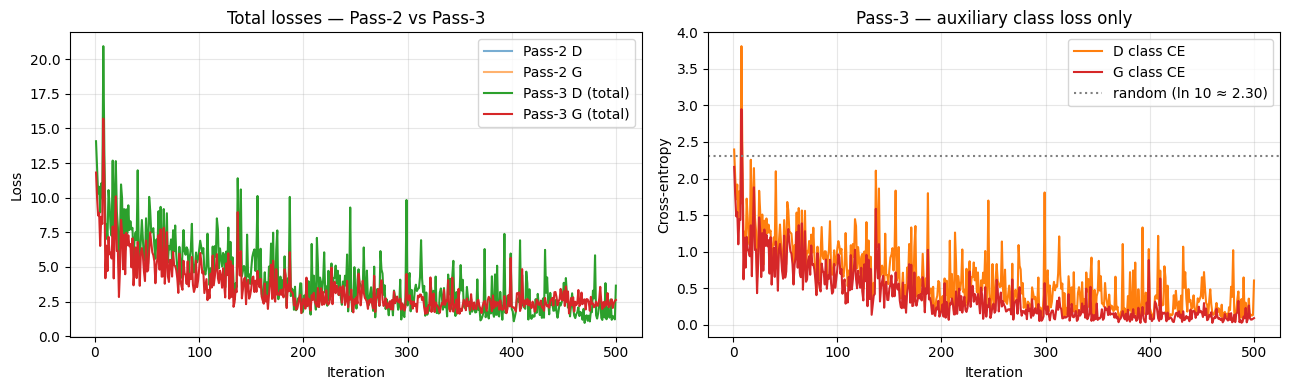

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

axes[0].plot(loss_history["iter"], loss_history["D"], label="Pass-2 D", alpha=0.6)
axes[0].plot(loss_history["iter"], loss_history["G"], label="Pass-2 G", alpha=0.6)
axes[0].plot(ac_loss_history["iter"], ac_loss_history["D"], label="Pass-3 D (total)", linewidth=1.5)
axes[0].plot(ac_loss_history["iter"], ac_loss_history["G"], label="Pass-3 G (total)", linewidth=1.5)
axes[0].set_title("Total losses — Pass-2 vs Pass-3")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(ac_loss_history["iter"], ac_loss_history["D_cls"],
             label="D class CE", color="tab:orange")
axes[1].plot(ac_loss_history["iter"], ac_loss_history["G_cls"],
             label="G class CE", color="tab:red")
axes[1].axhline(math.log(N_CLASSES), color="grey", linestyle=":",
                label=f"random (ln {N_CLASSES} ≈ {math.log(N_CLASSES):.2f})")
axes[1].set_title("Pass-3 — auxiliary class loss only")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Cross-entropy")
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

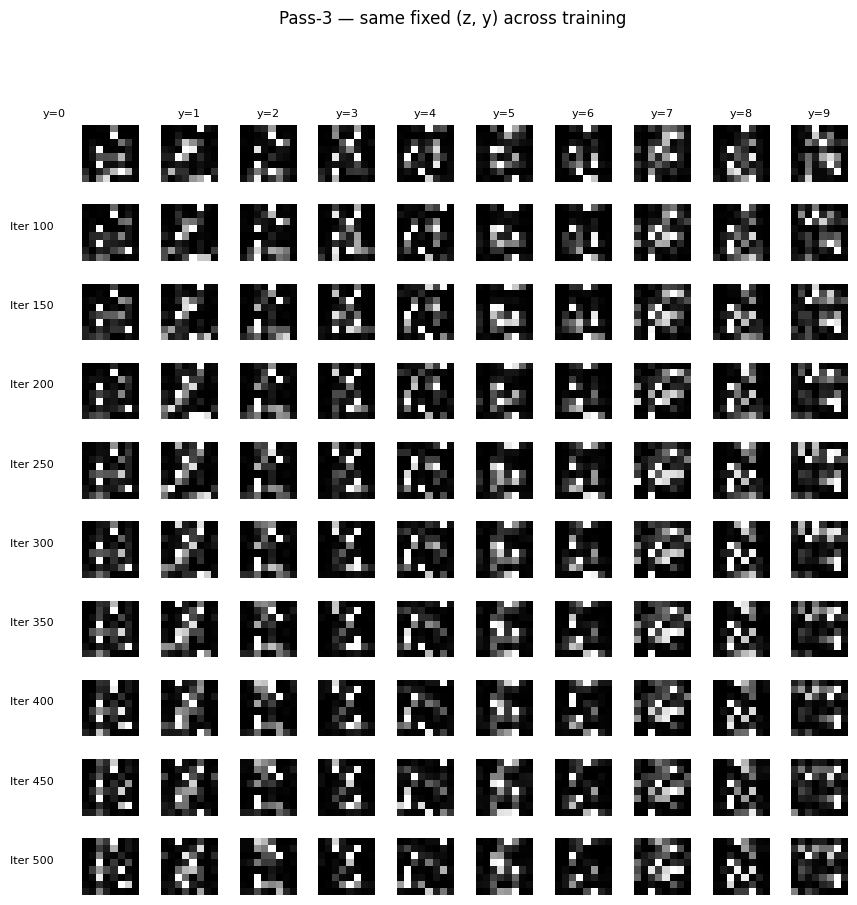

In [31]:
if ac_results:
    fig = plt.figure(figsize=(10, 1.0 * len(ac_results)))
    outer = gridspec.GridSpec(len(ac_results), 1, wspace=0.1, hspace=0.4)
    for i, snap in enumerate(ac_results):
        inner = gridspec.GridSpecFromSubplotSpec(1, N_CLASSES, subplot_spec=outer[i])
        for c in range(N_CLASSES):
            ax = plt.Subplot(fig, inner[c])
            ax.imshow(snap[c, 0].numpy(), cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if c == 0:
                ax.set_title(f"Iter {(i + 1) * 50}", x=-0.5, y=0.4, fontsize=8, ha="right")
            if i == 0:
                ax.set_title(f"y={c}", fontsize=8)
            fig.add_subplot(ax)
    fig.suptitle("Pass-3 — same fixed (z, y) across training", y=0.995)
    plt.show()
else:
    print("(No snapshots collected — re-run training cell to populate ac_results.)")

### 8.4 Final samples — 10 per class

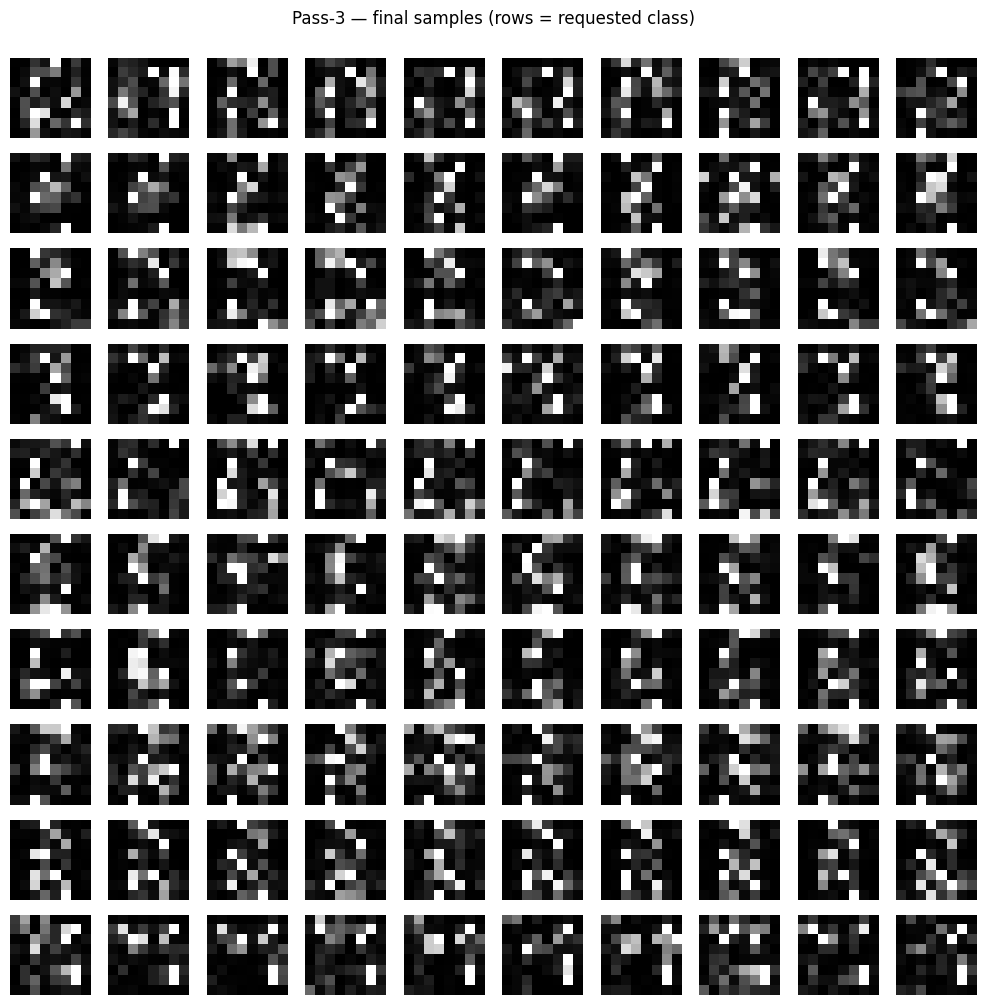

In [32]:
ac_samples_per_class = 10
with torch.no_grad():
    ac_z_grid = torch.rand(N_CLASSES * ac_samples_per_class, ac_qcfg.n_qubits, device=device) * math.pi / 2
    ac_y_grid = torch.arange(N_CLASSES, device=device).repeat_interleave(ac_samples_per_class)
    ac_grid = ac_generator(ac_z_grid, ac_y_grid).view(
        N_CLASSES, ac_samples_per_class, image_size, image_size
    ).cpu()

fig, axes = plt.subplots(N_CLASSES, ac_samples_per_class,
                         figsize=(ac_samples_per_class, N_CLASSES))
for c in range(N_CLASSES):
    for j in range(ac_samples_per_class):
        ax = axes[c, j]
        ax.imshow(ac_grid[c, j].numpy(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(f"y={c}", fontsize=9, rotation=0, labelpad=20, ha="right")
fig.suptitle("Pass-3 — final samples (rows = requested class)", y=1.0)
plt.tight_layout(); plt.show()

### 8.5 Quantitative evaluation — same metric suite as Pass 2

The judge, feature extractor, real-data tensors and `sample_inputs`
helpers from §7 are reused so that Pass-2 and Pass-3 are scored on
*identical* metrics.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


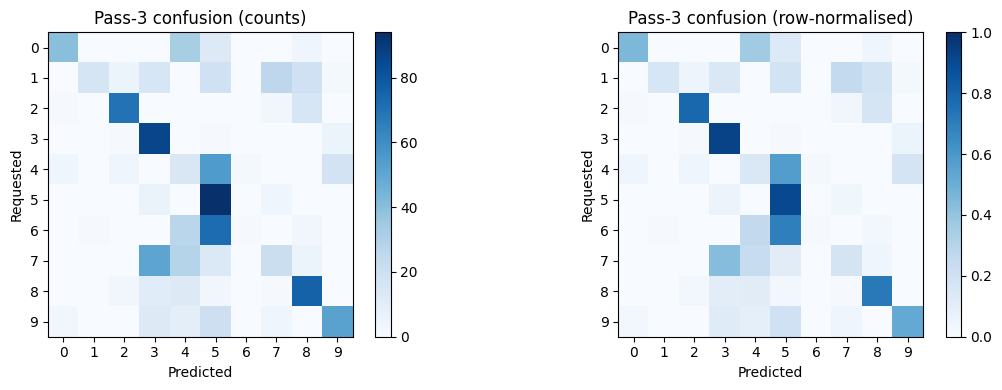

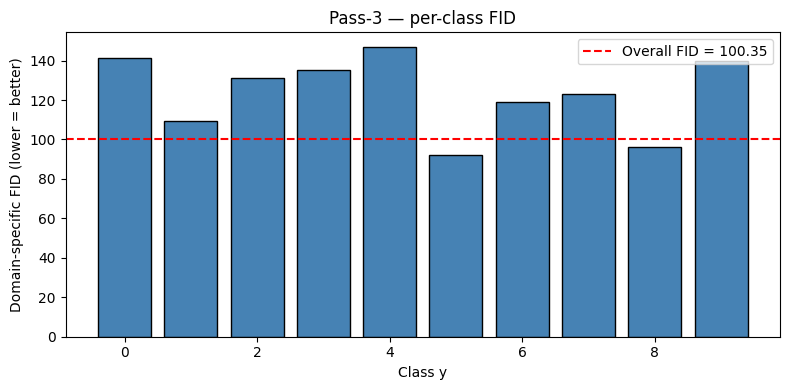

In [33]:
def ac_sample_inputs(n: int):
    """(z, y) sampler for the wider Pass-3 generator. Same n_qubits, so
    structurally identical to Pass-2's sample_inputs."""
    z = torch.rand(n, ac_qcfg.n_qubits, device=device) * math.pi / 2
    y = torch.randint(0, N_CLASSES, (n,), device=device)
    return (z, y)


def ac_sample_latent(n: int):
    return torch.rand(n, ac_qcfg.n_qubits, device=device) * math.pi / 2


ac_diversity = M.compute_pixel_diversity(
    ac_generator, ac_sample_inputs, device, n_samples=200
)
ac_judge_metrics = M.compute_judge_metrics(
    ac_generator, ac_sample_inputs, judge, device=device,
    n_samples=1000, n_classes=N_CLASSES,
)
ac_fid_overall = M.compute_custom_fid(
    ac_generator, ac_sample_inputs, real_images_t, feat_extractor,
    device=device, n_samples=1000,
)
ac_fid_per_class = M.compute_per_class_fid(
    ac_generator, real_images=real_images_t, real_labels=real_labels_t,
    extractor=feat_extractor, device=device,
    sample_latent=ac_sample_latent,
    n_samples_per_class=200, n_classes=N_CLASSES,
)
ac_gen_speed = M.measure_generation_speed(
    ac_generator, ac_sample_inputs, device=device, n_samples=200
)
if not SKIP_STANDARD_IS:
    ac_is_mean, ac_is_std = M.compute_inception_score(
        ac_generator, ac_sample_inputs, device=device, n_samples=400, splits=4,
    )
else:
    ac_is_mean, ac_is_std = float("nan"), float("nan")

# Pretty-print the confusion matrix (counts and row-normalised).
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cm = ac_judge_metrics["confusion_matrix"]
cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
for a, mat, title, vmax in [
    (ax[0], cm,      "Pass-3 confusion (counts)",        None),
    (ax[1], cm_norm, "Pass-3 confusion (row-normalised)", 1.0),
]:
    im = a.imshow(mat, cmap="Blues", vmin=0, vmax=vmax)
    a.set_xlabel("Predicted"); a.set_ylabel("Requested")
    a.set_xticks(range(N_CLASSES)); a.set_yticks(range(N_CLASSES))
    a.set_title(title)
    plt.colorbar(im, ax=a, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# Per-class FID bar chart.
classes = list(ac_fid_per_class.keys())
values = [ac_fid_per_class[c] for c in classes]
plt.figure(figsize=(8, 4))
plt.bar(classes, values, color="steelblue", edgecolor="black")
plt.axhline(ac_fid_overall, color="red", linestyle="--",
            label=f"Overall FID = {ac_fid_overall:.2f}")
plt.title("Pass-3 — per-class FID")
plt.xlabel("Class y"); plt.ylabel("Domain-specific FID (lower = better)")
plt.legend(); plt.tight_layout(); plt.show()

### 8.6 Side-by-side comparison — Pass 2 vs. Pass 3

metric                         |               Pass 2 |               Pass 3
------------------------------------------------------------------------------
generator_params               |                  170 |                  250
discriminator_params           |                 6401 |                 5387
training_time_sec              |                611.1 |               1543.3
overall_accuracy               |                0.209 |                0.480
mean_target_confidence         |                0.150 |                0.205
judge_inception_score          |                1.322 |                1.233
fid_overall                    |                50.82 |               100.35
inception_score_mean           |                1.002 |                1.001
mean_pairwise_l2               |               2.5002 |               2.9142
mean_pixel_std                 |               0.1907 |               0.2337
samples_per_sec                |                197.4 |                140

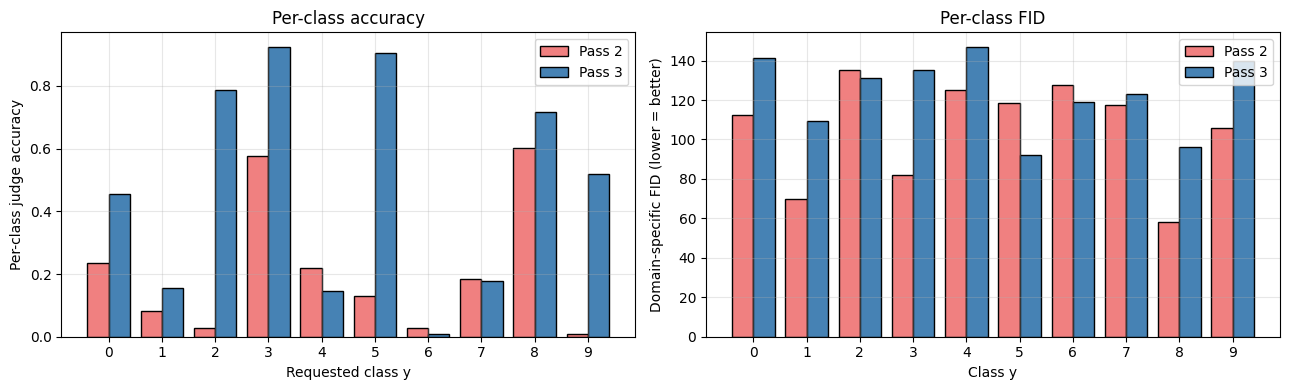

In [34]:
ac_quantum_metrics = {
    "model": "Conditional Quantum GAN — Pass 3 (AC-GAN + larger G)",
    "generator_params": M.count_parameters(ac_generator),
    "discriminator_params": M.count_parameters(ac_discriminator),
    "training_time_sec": float(ac_total_train_time),
    "fid_overall": float(ac_fid_overall),
    "fid_per_class": {int(c): float(v) for c, v in ac_fid_per_class.items()},
    "inception_score_mean": float(ac_is_mean),
    "inception_score_std": float(ac_is_std),
    "judge_inception_score": float(ac_judge_metrics["judge_inception_score"]),
    "overall_accuracy": float(ac_judge_metrics["overall_accuracy"]),
    "mean_target_confidence": float(ac_judge_metrics["mean_target_confidence"]),
    "per_class_accuracy": [float(a) for a in ac_judge_metrics["per_class_accuracy"]],
    "predicted_distribution": [int(c) for c in ac_judge_metrics["predicted_distribution"]],
    "mean_pairwise_l2": float(ac_diversity["mean_pairwise_l2"]),
    "mean_pixel_std": float(ac_diversity["mean_pixel_std"]),
    "samples_per_sec": float(ac_gen_speed),
}

# Side-by-side scoreboard.
print("=" * 78)
print(f"{'metric':30s} | {'Pass 2':>20s} | {'Pass 3':>20s}")
print("-" * 78)
fmt_keys = [
    ("generator_params",      "{:>20d}"),
    ("discriminator_params",  "{:>20d}"),
    ("training_time_sec",     "{:>20.1f}"),
    ("overall_accuracy",      "{:>20.3f}"),
    ("mean_target_confidence","{:>20.3f}"),
    ("judge_inception_score", "{:>20.3f}"),
    ("fid_overall",           "{:>20.2f}"),
    ("inception_score_mean",  "{:>20.3f}"),
    ("mean_pairwise_l2",      "{:>20.4f}"),
    ("mean_pixel_std",        "{:>20.4f}"),
    ("samples_per_sec",       "{:>20.1f}"),
]
for k, fmt in fmt_keys:
    p2 = quantum_metrics.get(k, float("nan"))
    p3 = ac_quantum_metrics.get(k, float("nan"))
    print(f"{k:30s} | {fmt.format(p2)} | {fmt.format(p3)}")
print("=" * 78)

# Per-class accuracy + per-class FID side-by-side bar charts.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(N_CLASSES); w = 0.4
axes[0].bar(x - w / 2, quantum_metrics["per_class_accuracy"], w, label="Pass 2",
            color="lightcoral", edgecolor="black")
axes[0].bar(x + w / 2, ac_quantum_metrics["per_class_accuracy"], w, label="Pass 3",
            color="steelblue", edgecolor="black")
axes[0].set_xticks(x); axes[0].set_xlabel("Requested class y")
axes[0].set_ylabel("Per-class judge accuracy")
axes[0].set_title("Per-class accuracy"); axes[0].grid(alpha=0.3); axes[0].legend()

p2_fid = [quantum_metrics["fid_per_class"][c] for c in range(N_CLASSES)]
p3_fid = [ac_quantum_metrics["fid_per_class"][c] for c in range(N_CLASSES)]
axes[1].bar(x - w / 2, p2_fid, w, label="Pass 2", color="lightcoral", edgecolor="black")
axes[1].bar(x + w / 2, p3_fid, w, label="Pass 3", color="steelblue", edgecolor="black")
axes[1].set_xticks(x); axes[1].set_xlabel("Class y")
axes[1].set_ylabel("Domain-specific FID (lower = better)")
axes[1].set_title("Per-class FID"); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

In [35]:
torch.save(
    {
        "generator_state_dict": ac_generator.state_dict(),
        "discriminator_state_dict": ac_discriminator.state_dict(),
        "qcfg": ac_qcfg.__dict__,
        "n_generators": ac_n_generators,
        "n_classes": N_CLASSES,
        "loss_history": ac_loss_history,
        "metrics": ac_quantum_metrics,
        "lambda_cls": ac_lambda_cls,
    },
    "quantum_gan_ac.pt",
)
print("Saved quantum_gan_ac.pt")

Saved quantum_gan_ac.pt
